In [209]:
import cv2                                                        #Importin librarey openCV
import matplotlib.pyplot as plt                                   #Importing matplotlib for plotting
from google.colab.patches import cv2_imshow                       #For displaying images

Here I downloaded the image from github. The source for this code is https://stackoverflow.com/questions/62974711/how-to-download-an-image-from-the-internet-using-google-colab-jupyter 

In [ ]:
from google.colab import files as FILE
import requests
img_data = requests.get("https://github.com/sakshiheda/EE610/blob/main/Image_orig.jpg?raw=true").content
with open('image1.jpg', 'wb') as handler:
    handler.write(img_data)

FILE.download('image1.jpg')

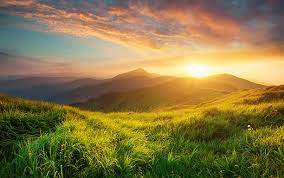

In [211]:
img_orig = cv2.imread("/content/image1.jpg")                                    #Reading the image to variable img_orig
cv2_imshow(img_orig)                                                            #Displaying the image

In [212]:
print(img_orig.shape)                                                                           

(178, 284, 3)


The shape of the image gives height, width of image and the third one represents RGB.
Next I have increased the values of all pixels by 50

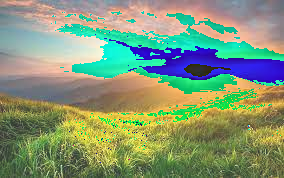

In [213]:
img_50 = img_orig + 50
cv2_imshow(img_50)

Then I took some of the center pixels and changed there values to 255 (i.e., white)

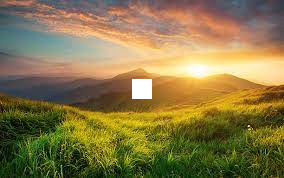

In [214]:
img_255 = img_orig                                                        
img_255[79:99, 132:152, 0:3] = 255                                              # A patch of White(255), particular pixels are edited
cv2_imshow(img_255)

Changing pixel values to 256

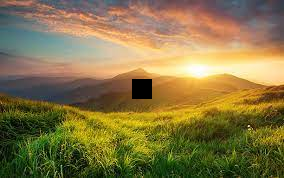

In [216]:
img_256 = img_orig
img_256[79:99, 132:152, 0:3] = 256                                              # A patch of Black(256), particular pixels are edited
cv2_imshow(img_256)

Cropping the image

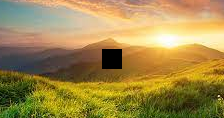

In [217]:
img_cropped = img_orig[30:148, 30:254, 0:3]                                     #Cropping the image, only the specified height and width will be displayed
cv2_imshow(img_cropped)

Next I created a new file and saved the cropped image there. For this I referred to https://www.geeksforgeeks.org/python-opencv-cv2-imwrite-method/

In [218]:
filename = "new.png"                                                            #Creating a new file
cv2.imwrite(filename, img_cropped)                                              #Writing the cropped image to the file

True

For flipping the image I referred to https://www.geeksforgeeks.org/python-opencv-cv2-flip-method/ 

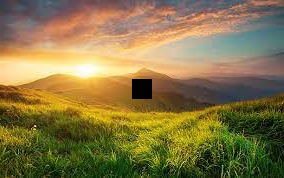

In [219]:
img_inv = cv2.flip(img_orig, 1)
cv2_imshow(img_inv)

Here I imported a night image which I had uploaded to github and converted it to grayscale

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

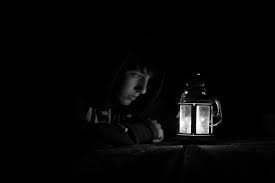

In [221]:
from google.colab import files as FILE
import requests
img_data = requests.get("https://github.com/sakshiheda/EE610/blob/main/Night.jpg?raw=true").content
with open('image2.jpg', 'wb') as handler:
    handler.write(img_data)

FILE.download('image2.jpg')
img_dark = cv2.imread("/content/image2.jpg", 0)                                 #Reading the image to variable img_orig
cv2_imshow(img_dark)  

Displaying the histogram 
Source: https://docs.opencv.org/4.x/d1/db7/tutorial_py_histogram_begins.html 

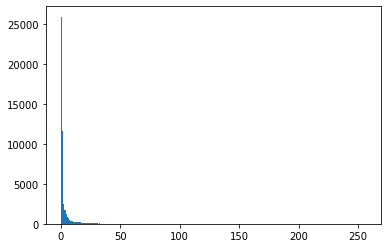

In [222]:
plt.hist(img_dark.ravel(),256,[0,256]);                                         # Getting the histogram
plt.show()

I then tried different values to brighten the image and found this one(1.75) to be best since after that image starts getting damaged

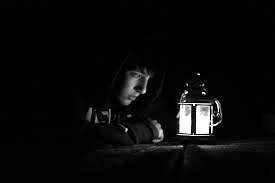

In [223]:
img_dark_bright = img_dark*1.75                                                 #Brightening the image by scaling up the pixel values
cv2_imshow(img_dark_bright)

Using Power Transformation

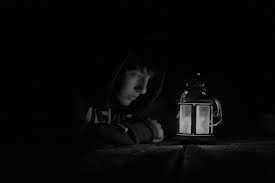

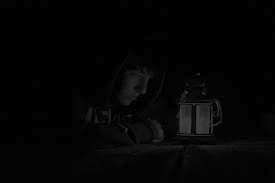

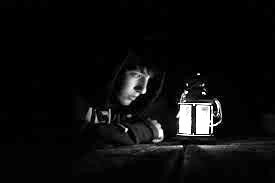

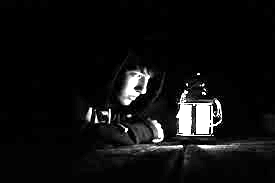

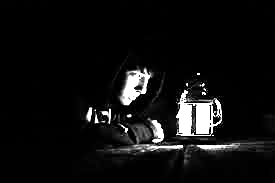

In [225]:
img_dark_power = 3.5*(img_dark)**0.7
cv2_imshow(img_dark_power)
img_dark_power = 4*(img_dark)**0.5
cv2_imshow(img_dark_power)
img_dark_power = 3.9*(img_dark)**0.9
cv2_imshow(img_dark_power)
img_dark_power = 3.1*(img_dark)**1.1
cv2_imshow(img_dark_power)
img_dark_power = 1.1*(img_dark)**1.5
cv2_imshow(img_dark_power)

The best gamma is around 0.9 as we can see from above

Next is Histogram equalization
Source: https://www.geeksforgeeks.org/histograms-equalization-opencv/#:~:text=Histogram%20equalization%20is%20a%20method,represented%20by%20close%20contrast%20values. 

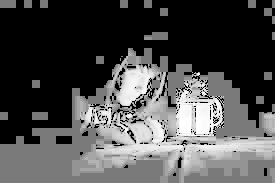

In [226]:
img_hist = cv2.equalizeHist(img_dark)
cv2_imshow(img_hist)

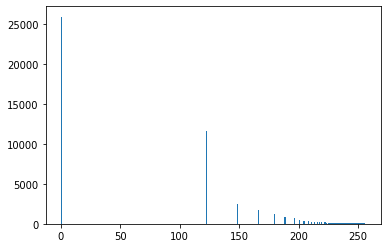

In [ ]:
plt.hist(img_hist.ravel(),256,[0,256]);                                         #Plotting the new histogram
plt.show()